In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('cytology_simulation_results.csv')

# Round numeric columns to 3 decimal places
numeric_cols = ['arrival_time_sim', 'total_time_in_system_days', 
                'fixation_start_sim', 'fixation_end_sim', 'fixation_duration_days',
                'staining_start_sim', 'staining_end_sim', 'staining_duration_days',
                'reporting_start_sim', 'reporting_end_sim', 'reporting_duration_days',
                'waiting_for_staining_days', 'waiting_for_reporting_days']

# Round only columns that exist in the dataframe
for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].round(3)

df.head()

,slide_id,entity_type,is_pap,is_positive,arrival_time_sim,arrival_time,entry_time,exit_time,total_time_in_system_days,fixation_start_sim,...,staining_end,reporting_start_sim,reporting_start,reporting_end_sim,reporting_end,fixation_duration_days,staining_duration_days,reporting_duration_days,waiting_for_staining_days,waiting_for_reporting_days
0,1,cyto_slide,True,False,0.000,09:00 01/05/25,09:00 01/05/25,09:36 02/05/25,1.025,0.010,...,12:12 01/05/25,1.020,09:28 02/05/25,1.025,09:36 02/05/25,0.01,0.014,0.005,0.100,0.886
1,1,cyto_slide,False,NaN,0.000,09:00 01/05/25,09:00 01/05/25,13:14 02/05/25,1.177,0.020,...,12:12 01/05/25,1.175,13:12 02/05/25,1.177,13:14 02/05/25,0.01,0.014,0.002,0.089,1.041
2,2,cyto_slide,False,NaN,0.022,09:31 01/05/25,09:31 01/05/25,13:34 02/05/25,1.169,0.031,...,12:12 01/05/25,1.177,13:14 02/05/25,1.191,13:34 02/05/25,0.01,0.014,0.014,0.079,1.043
3,2,cyto_slide,True,False,0.023,09:32 01/05/25,09:32 01/05/25,15:58 02/05/25,1.268,0.041,...,12:12 01/05/25,1.291,15:58 02/05/25,1.291,15:58 02/05/25,0.01,0.014,0.000,0.068,1.157
4,3,cyto_slide,False,NaN,0.024,09:34 01/05/25,09:34 01/05/25,16:11 02/05/25,1.276,0.052,...,12:12 01/05/25,1.291,15:58 02/05/25,1.300,16:11 02/05/25,0.01,0.014,0.009,0.058,1.157


In [11]:
# Check available columns
print("Available columns:")
print(df.columns.tolist())
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Available columns:
['slide_id', 'entity_type', 'is_pap', 'is_positive', 'arrival_time_sim', 'arrival_time', 'entry_time', 'exit_time', 'total_time_in_system_days', 'fixation_start_sim', 'fixation_start', 'fixation_end_sim', 'fixation_end', 'staining_start_sim', 'staining_start', 'staining_end_sim', 'staining_end', 'reporting_start_sim', 'reporting_start', 'reporting_end_sim', 'reporting_end', 'fixation_duration_days', 'staining_duration_days', 'reporting_duration_days', 'waiting_for_staining_days', 'waiting_for_reporting_days']

DataFrame shape: (22731, 26)

First few rows:


,slide_id,entity_type,is_pap,is_positive,arrival_time_sim,arrival_time,entry_time,exit_time,total_time_in_system_days,fixation_start_sim,...,staining_end,reporting_start_sim,reporting_start,reporting_end_sim,reporting_end,fixation_duration_days,staining_duration_days,reporting_duration_days,waiting_for_staining_days,waiting_for_reporting_days
0,1,cyto_slide,True,False,0.000,09:00 01/05/25,09:00 01/05/25,09:36 02/05/25,1.025,0.010,...,12:12 01/05/25,1.020,09:28 02/05/25,1.025,09:36 02/05/25,0.01,0.014,0.005,0.100,0.886
1,1,cyto_slide,False,NaN,0.000,09:00 01/05/25,09:00 01/05/25,13:14 02/05/25,1.177,0.020,...,12:12 01/05/25,1.175,13:12 02/05/25,1.177,13:14 02/05/25,0.01,0.014,0.002,0.089,1.041
2,2,cyto_slide,False,NaN,0.022,09:31 01/05/25,09:31 01/05/25,13:34 02/05/25,1.169,0.031,...,12:12 01/05/25,1.177,13:14 02/05/25,1.191,13:34 02/05/25,0.01,0.014,0.014,0.079,1.043
3,2,cyto_slide,True,False,0.023,09:32 01/05/25,09:32 01/05/25,15:58 02/05/25,1.268,0.041,...,12:12 01/05/25,1.291,15:58 02/05/25,1.291,15:58 02/05/25,0.01,0.014,0.000,0.068,1.157
4,3,cyto_slide,False,NaN,0.024,09:34 01/05/25,09:34 01/05/25,16:11 02/05/25,1.276,0.052,...,12:12 01/05/25,1.291,15:58 02/05/25,1.300,16:11 02/05/25,0.01,0.014,0.009,0.058,1.157


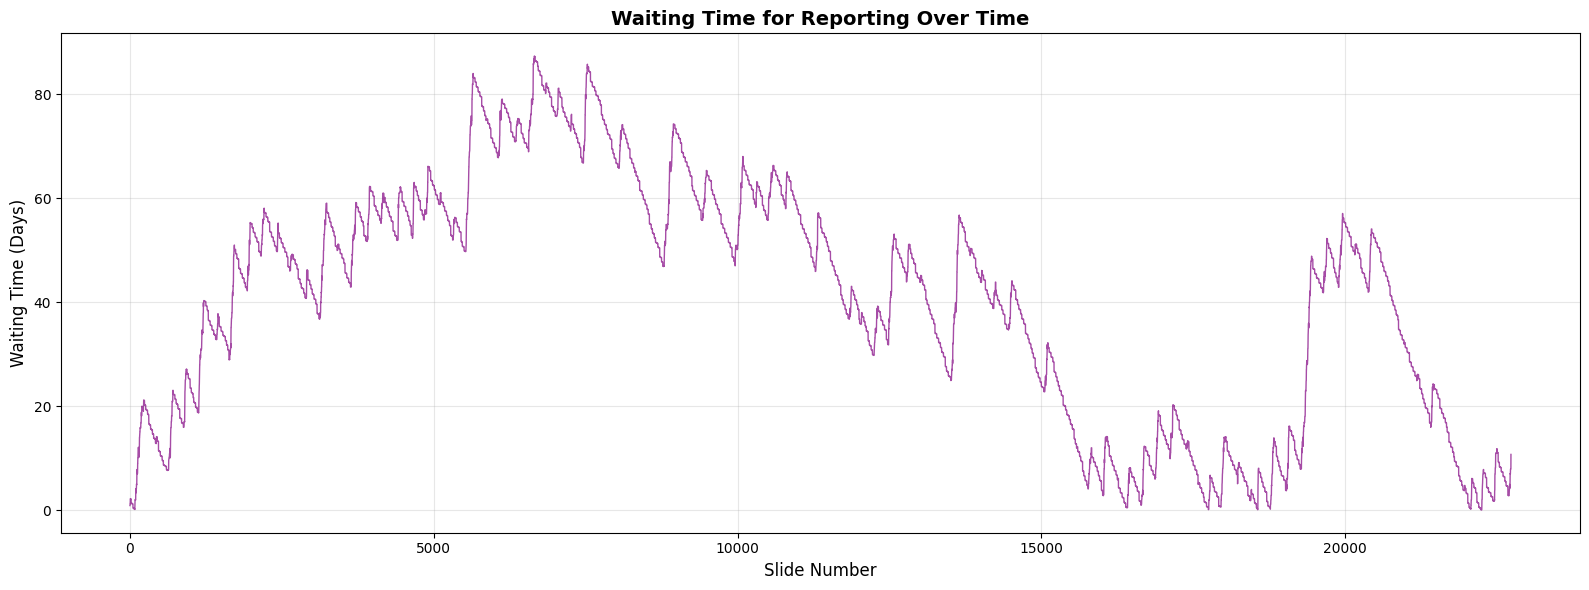


Waiting Time for Reporting Statistics:
  Mean:   40.365 days
  Median: 44.628 days
  Std:    23.099 days
  Min:    0.026 days
  Max:    87.305 days


In [12]:
# Plot waiting time for reporting
plt.figure(figsize=(16, 6))

plt.plot(df.index, df['waiting_for_reporting_days'], linewidth=1, alpha=0.7, color='purple')
plt.xlabel('Slide Number', fontsize=12)
plt.ylabel('Waiting Time (Days)', fontsize=12)
plt.title('Waiting Time for Reporting Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nWaiting Time for Reporting Statistics:")
print(f"  Mean:   {df['waiting_for_reporting_days'].mean():.3f} days")
print(f"  Median: {df['waiting_for_reporting_days'].median():.3f} days")
print(f"  Std:    {df['waiting_for_reporting_days'].std():.3f} days")
print(f"  Min:    {df['waiting_for_reporting_days'].min():.3f} days")
print(f"  Max:    {df['waiting_for_reporting_days'].max():.3f} days")